In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
sns.set_style("darkgrid")
mpl.rcParams['figure.figsize'] = (20,5)

In [3]:
data='E:/stroke_data.csv'

dataframe=pd.read_csv(data,header=0)
#dataframe_raw.head()
#dataframe_stdev.head()

print("##### Data Description ####")
print(dataframe.describe())
print("##### Data Info ####")
print(dataframe.info())
print("##### DataFrame ####")
dataframe

##### Data Description ####
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           1

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [5]:
dataframe = dataframe.drop_duplicates()
dataframe = dataframe.dropna(subset=['bmi'])

In [7]:
dataframe

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [13]:
dataframe['gender']=dataframe['gender'].replace({'Male': 1,'Female': 0}).infer_objects(copy=False)
dataframe['ever_married']=dataframe['ever_married'].replace({'Yes': 1,'No': 0}).infer_objects(copy=False)
dataframe['work_type']=dataframe['work_type'].replace({'Private': 0,'Self-employed': 1,'Govt_job': 2}).infer_objects(copy=False)
dataframe['Residence_type']=dataframe['Residence_type'].replace({'Urban': 1,'Rural': 0}).infer_objects(copy=False)
dataframe['smoking_status']=dataframe['smoking_status'].replace({'smokes': 1,'never smoked': 0,'formerly smoked': 2, 'Unknown': 3}).infer_objects(copy=False)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,0,1,228.69,36.6,2,1
2,31112,1,80.0,0,1,1,0,0,105.92,32.5,0,1
3,60182,0,49.0,0,0,1,0,1,171.23,34.4,1,1
4,1665,0,79.0,1,0,1,1,0,174.12,24.0,0,1
5,56669,1,81.0,0,0,1,0,1,186.21,29.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,0,13.0,0,0,0,children,0,103.08,18.6,3,0
5106,44873,0,81.0,0,0,1,1,1,125.20,40.0,0,0
5107,19723,0,35.0,0,0,1,1,0,82.99,30.6,0,0
5108,37544,1,51.0,0,0,1,0,0,166.29,25.6,2,0


In [15]:
dataframe = dataframe.drop('id',axis = 1)

In [17]:
dataframe

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,1,228.69,36.6,2,1
2,1,80.0,0,1,1,0,0,105.92,32.5,0,1
3,0,49.0,0,0,1,0,1,171.23,34.4,1,1
4,0,79.0,1,0,1,1,0,174.12,24.0,0,1
5,1,81.0,0,0,1,0,1,186.21,29.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,0,13.0,0,0,0,children,0,103.08,18.6,3,0
5106,0,81.0,0,0,1,1,1,125.20,40.0,0,0
5107,0,35.0,0,0,1,1,0,82.99,30.6,0,0
5108,1,51.0,0,0,1,0,0,166.29,25.6,2,0


In [19]:
dataframe = dataframe[~dataframe['work_type'].str.contains('children', na=False)]

In [21]:
dataframe

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,1,228.69,36.6,2,1
2,1,80.0,0,1,1,0,0,105.92,32.5,0,1
3,0,49.0,0,0,1,0,1,171.23,34.4,1,1
4,0,79.0,1,0,1,1,0,174.12,24.0,0,1
5,1,81.0,0,0,1,0,1,186.21,29.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
5103,0,18.0,0,0,0,0,1,82.85,46.9,3,0
5106,0,81.0,0,0,1,1,1,125.20,40.0,0,0
5107,0,35.0,0,0,1,1,0,82.99,30.6,0,0
5108,1,51.0,0,0,1,0,0,166.29,25.6,2,0


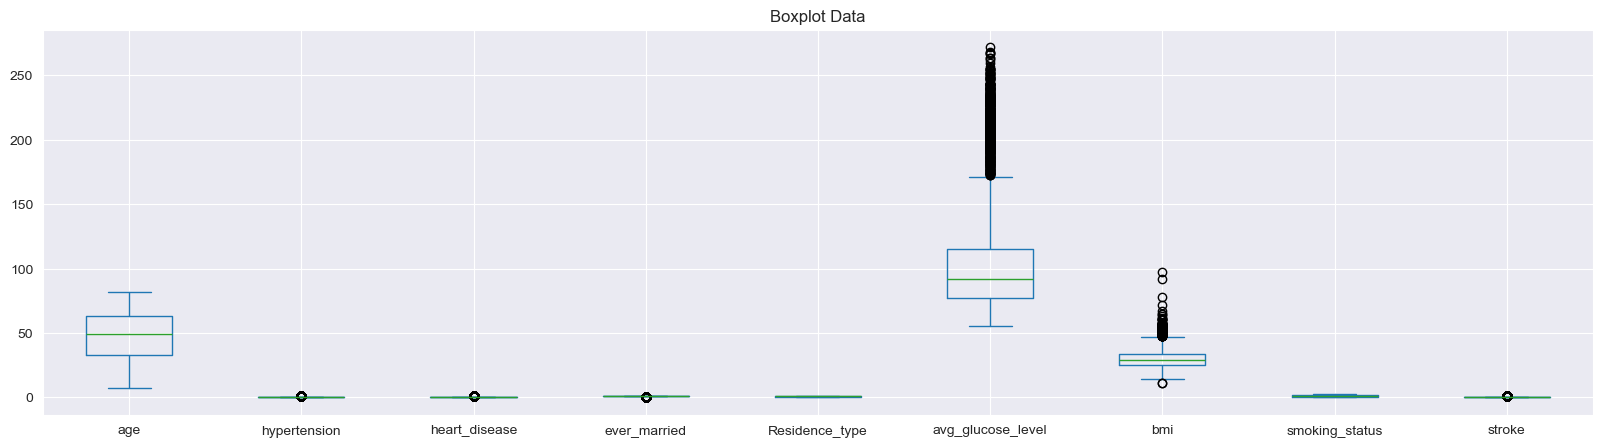

In [23]:
dataframe.plot(kind='box',title = 'Boxplot Data')
plt.show()

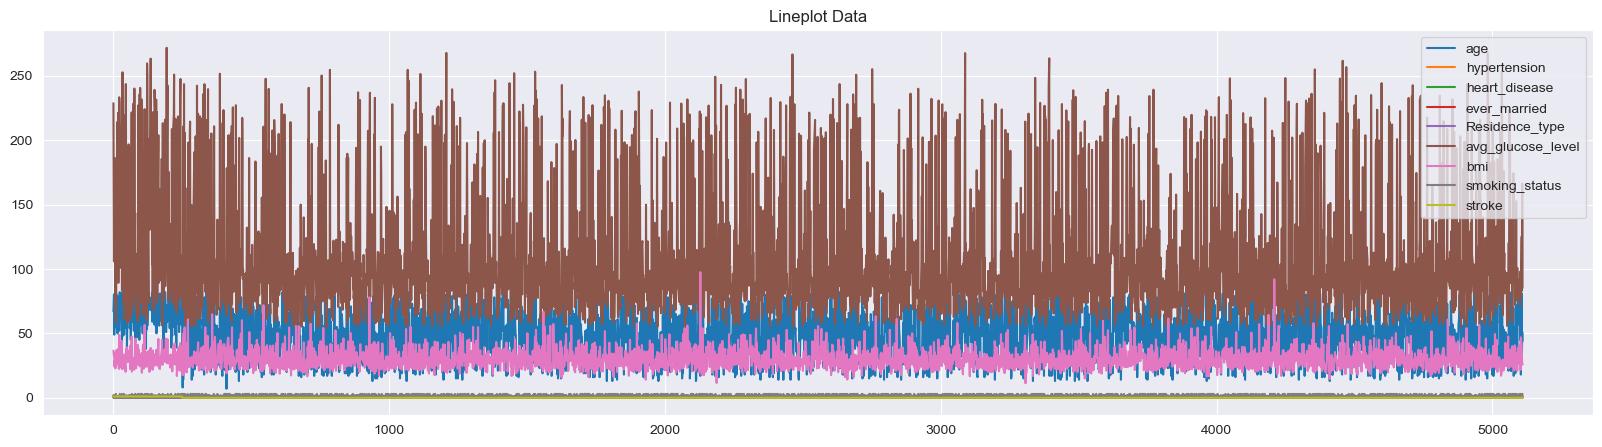

In [25]:
dataframe.plot(kind='line',title = 'Lineplot Data')
plt.show()

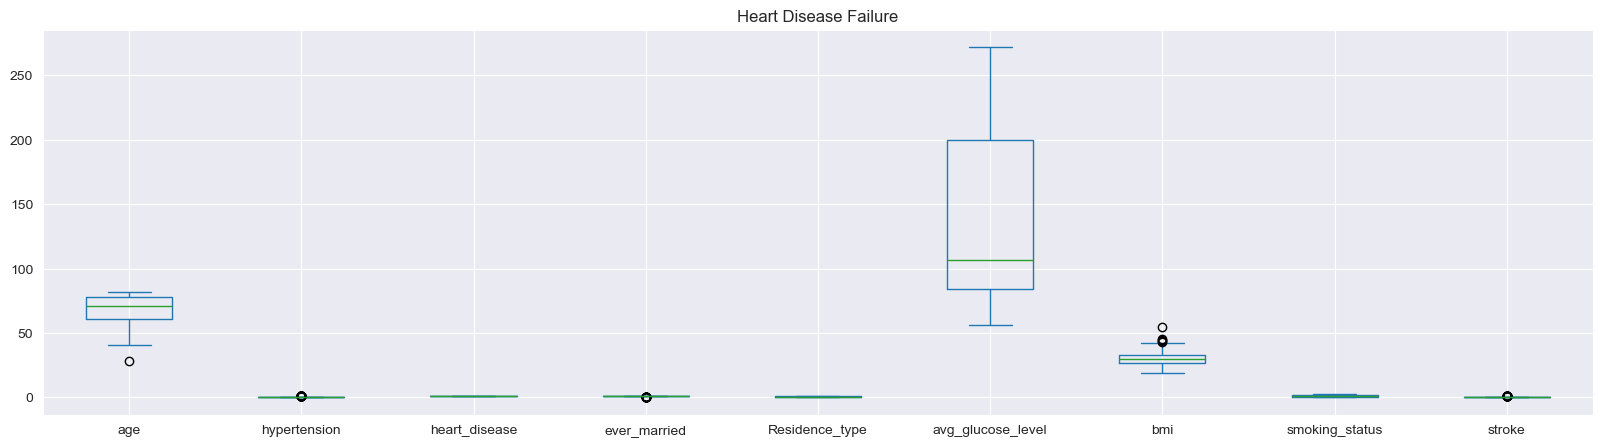

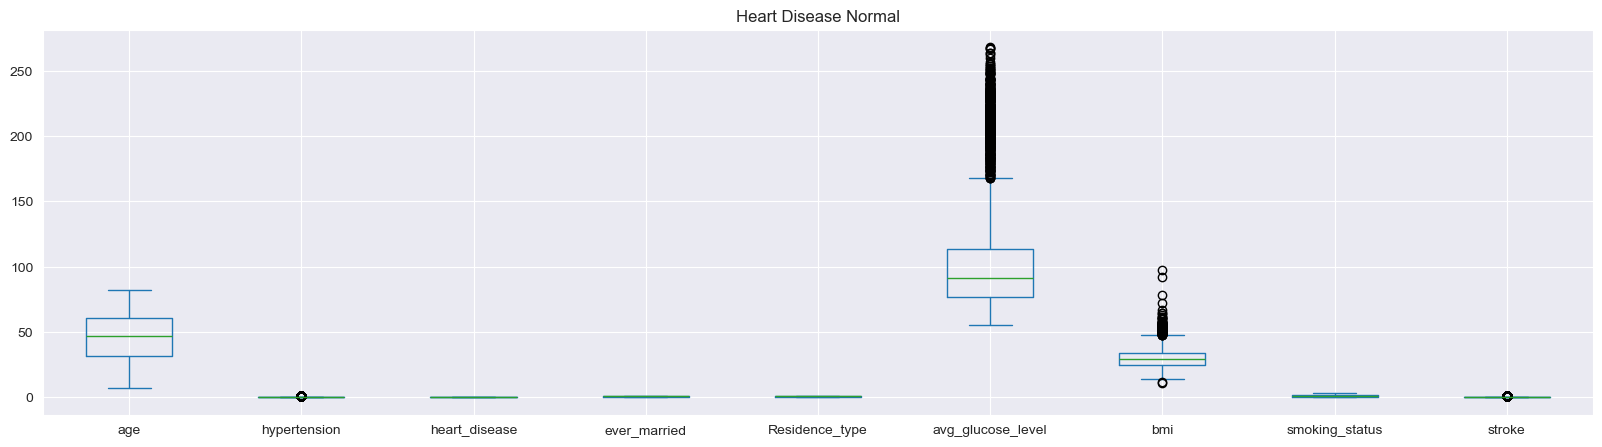

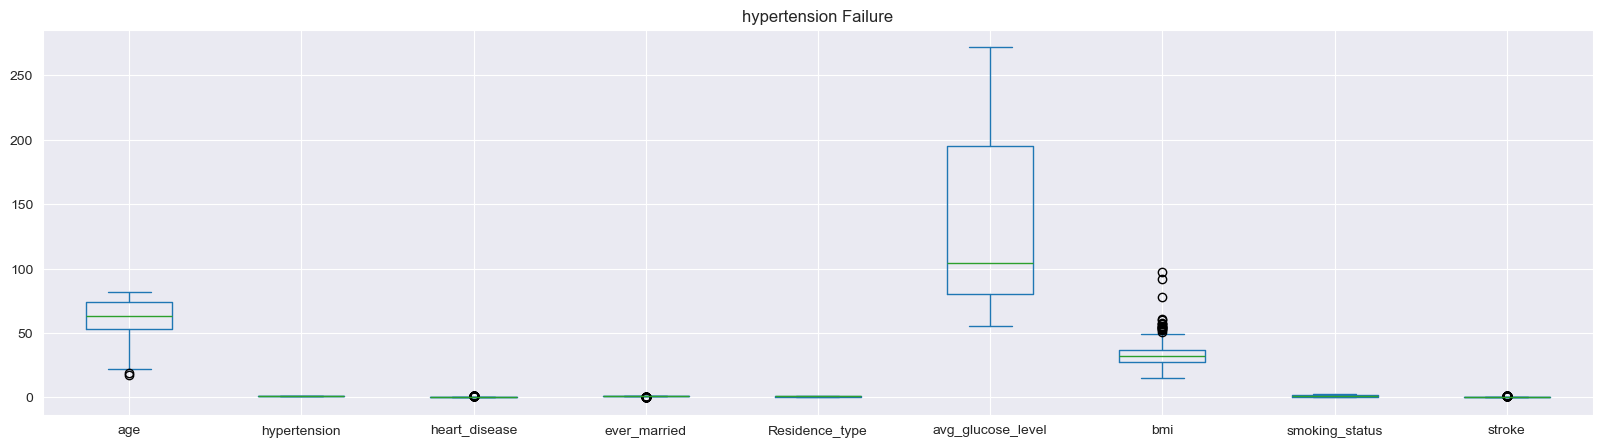

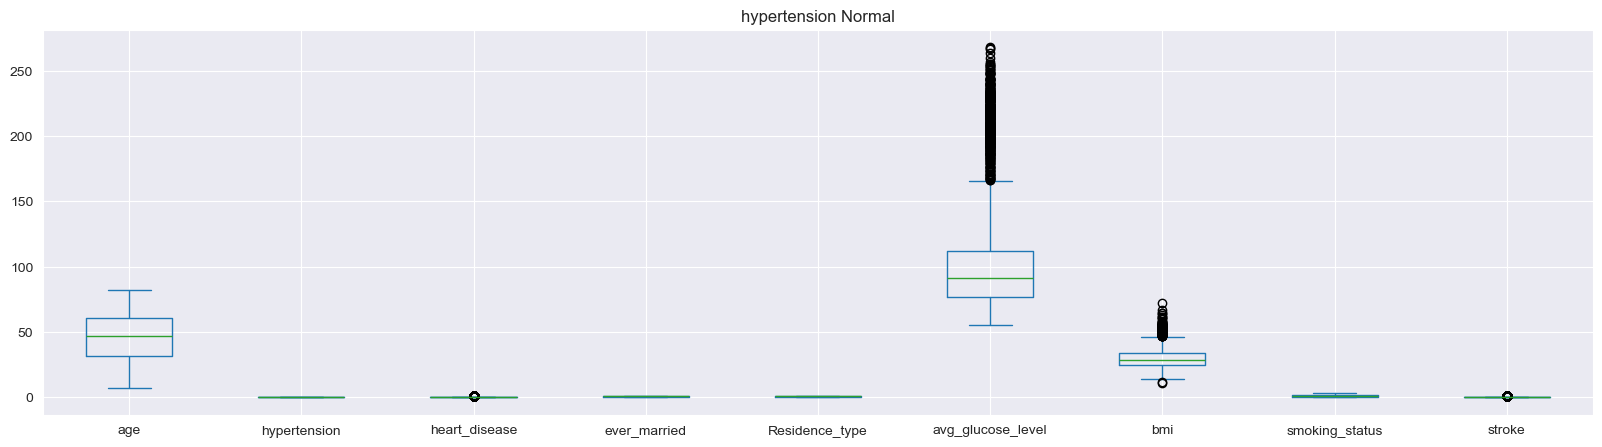

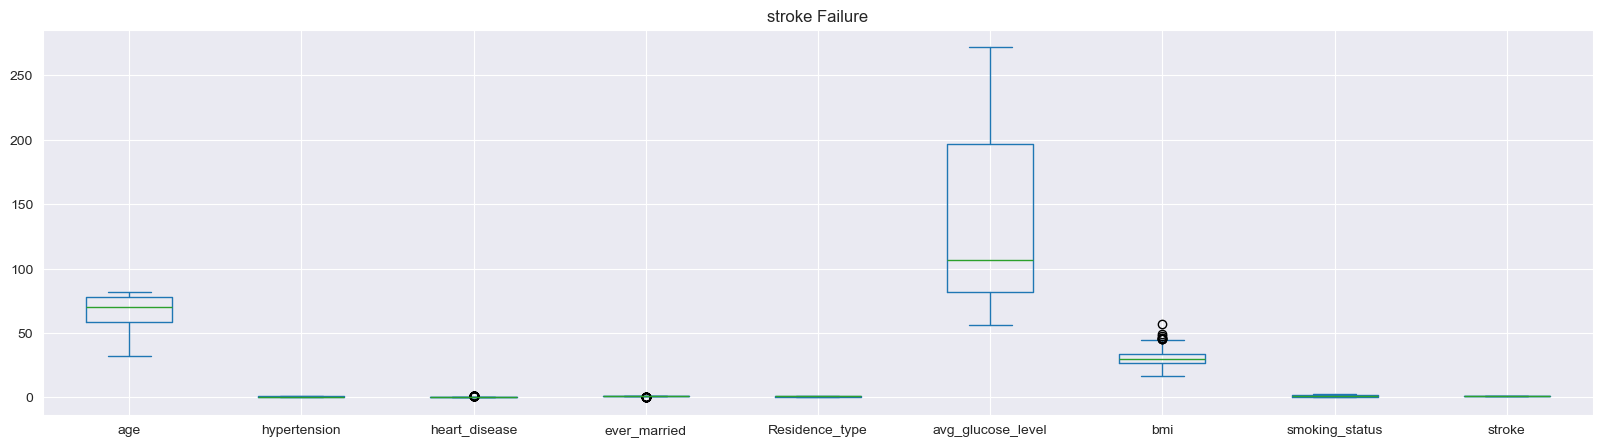

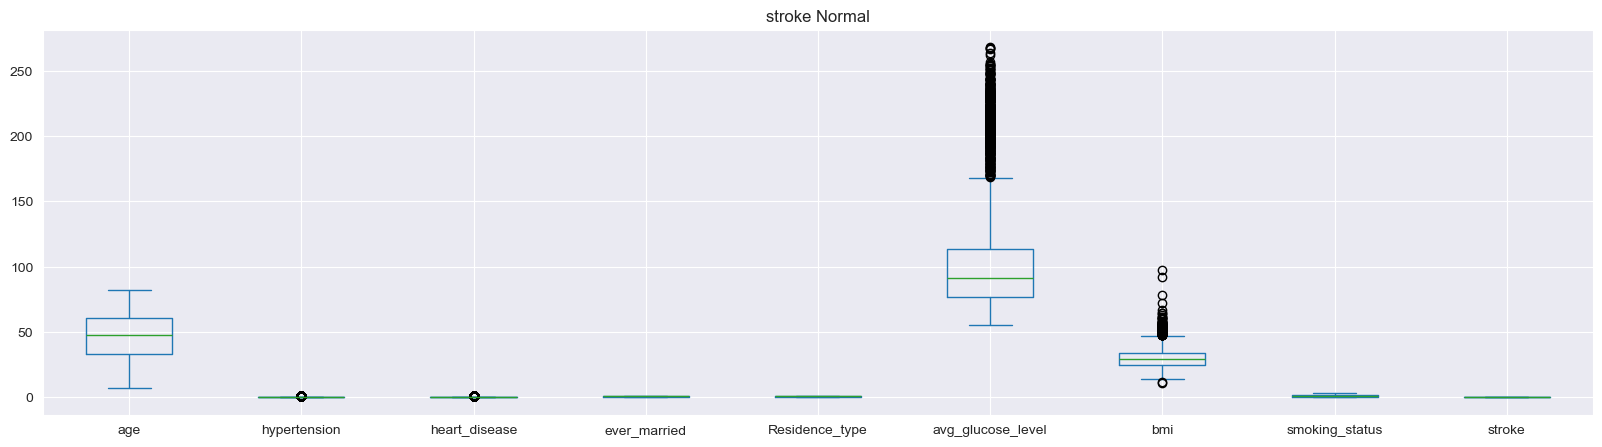

In [27]:
condition_1 = dataframe['heart_disease']== 1
dataframe_heart_disease_Failure = dataframe[condition_1] 
dataframe_heart_disease_Failure.plot(kind='box')
plt.title("Heart Disease Failure")
plt.show()
condition_2 = dataframe['heart_disease']== 0
dataframe_heart_disease_Normal = dataframe[condition_2] 
dataframe_heart_disease_Normal.plot(kind='box')
plt.title("Heart Disease Normal")
plt.show()
condition_3 = dataframe['hypertension']== 1
dataframe_hypertension_Failure = dataframe[condition_3] 
dataframe_hypertension_Failure.plot(kind='box')
plt.title("hypertension Failure")
plt.show()
condition_4 = dataframe['hypertension']== 0
dataframe_hypertension_Normal = dataframe[condition_4] 
dataframe_hypertension_Normal.plot(kind='box')
plt.title("hypertension Normal")
plt.show()
condition_5 = dataframe['stroke']== 1
dataframe_stroke_Failure = dataframe[condition_5] 
dataframe_stroke_Failure.plot(kind='box')
plt.title("stroke Failure")
plt.show()
condition_6 = dataframe['stroke']== 0
dataframe_stroke_Normal = dataframe[condition_6] 
dataframe_stroke_Normal.plot(kind='box')
plt.title("stroke Normal")
plt.show()

In [29]:
Q3 = dataframe.quantile(0.75,numeric_only=True)
Q1 = dataframe.quantile(0.25,numeric_only=True)
IQR=Q3-Q1
print(IQR)

age                  30.0000
hypertension          0.0000
heart_disease         0.0000
ever_married          0.0000
Residence_type        1.0000
avg_glucose_level    37.8175
bmi                   8.8000
smoking_status        2.0000
stroke                0.0000
dtype: float64


In [31]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = dataframe[((dataframe[IQR.index] < lower_limit) | ((dataframe[IQR.index] > upper_limit))).any(axis=1)]
print(len(outliers))
print(len(dataframe)/len(outliers))

2042
2.0754162585700295


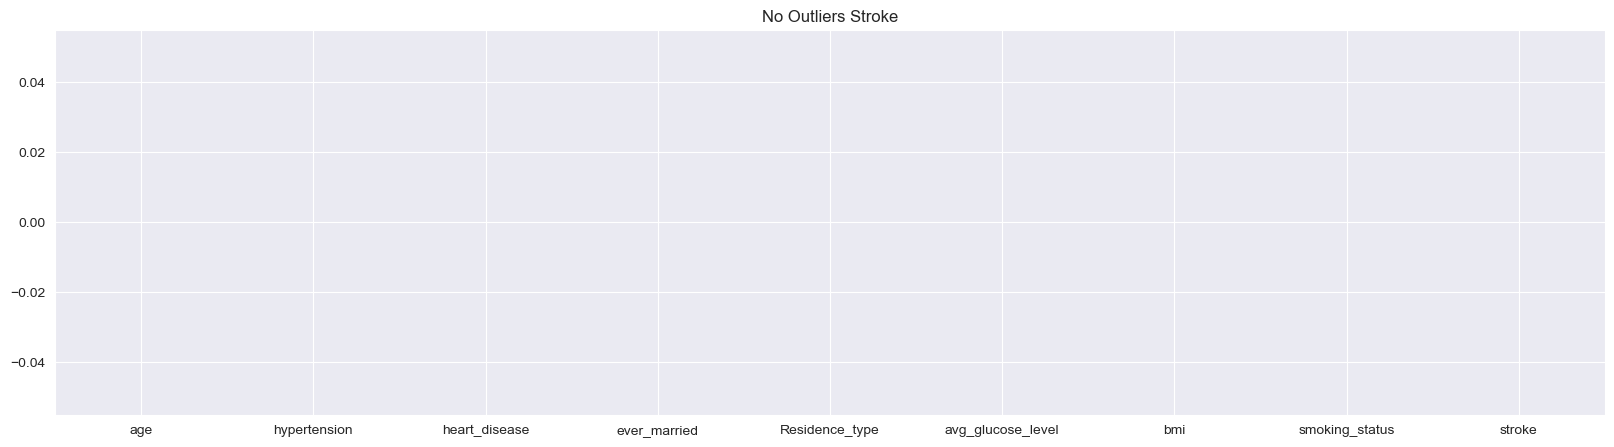

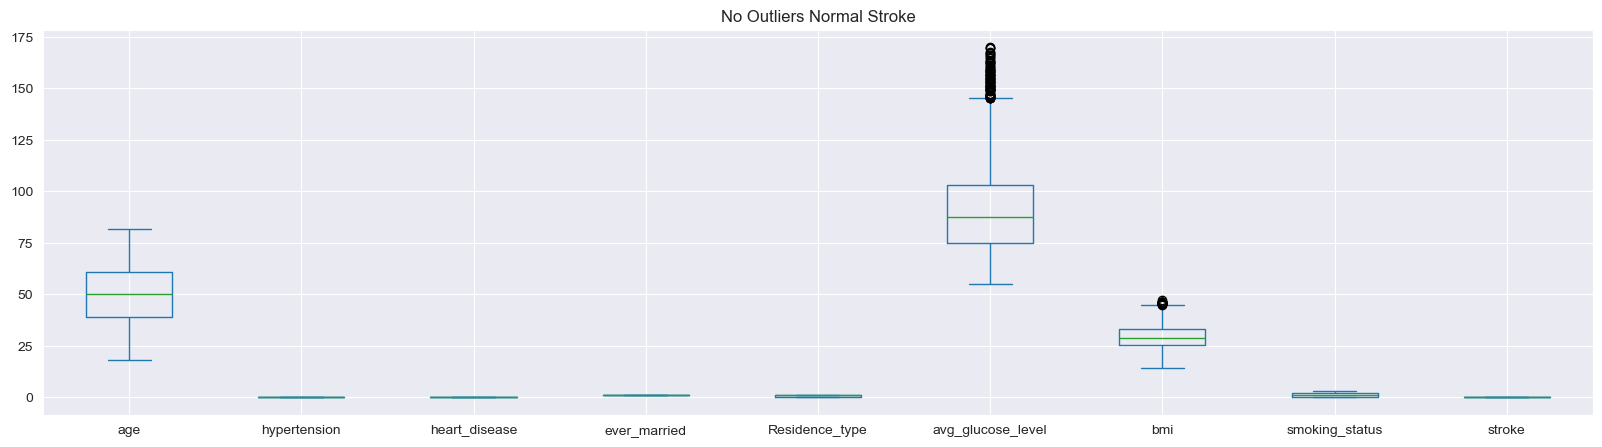

In [33]:
no_outliers = dataframe[~((dataframe[IQR.index] < lower_limit) | ((dataframe[IQR.index] > upper_limit))).any(axis=1)]
condition_1 = no_outliers['stroke']== 1
dataframe_no_outliers_Failure = no_outliers[condition_1] 
dataframe_no_outliers_Failure.plot(kind='box')
plt.title("No Outliers Stroke")
plt.show()
condition_2 = no_outliers['stroke']== 0
dataframe_no_outliers_Normal = no_outliers[condition_2] 
dataframe_no_outliers_Normal.plot(kind='box')
plt.title("No Outliers Normal Stroke")
plt.show()

In [35]:
correlated_dataframe = dataframe.corr(numeric_only = True)
sns.heatmap(correlated_dataframe, annot=True)

<Axes: >

In [37]:
correlated_dataframe = dataframe.corr(numeric_only=True).sort_values('stroke', ascending=False)

print(correlated_dataframe)

                        age  hypertension  heart_disease  ever_married  \
stroke             0.236225      0.134116       0.132377      0.073111   
age                1.000000      0.254414       0.263509      0.518917   
avg_glucose_level  0.228856      0.174051       0.151475      0.118124   
hypertension       0.254414      1.000000       0.106339      0.112308   
heart_disease      0.263509      0.106339       1.000000      0.075872   
ever_married       0.518917      0.112308       0.075872      1.000000   
Residence_type     0.013956     -0.001549      -0.003833      0.004452   
bmi                0.063470      0.128978       0.000838      0.133310   
smoking_status     0.023473     -0.066738       0.013730     -0.005536   

                   Residence_type  avg_glucose_level       bmi  \
stroke                   0.007385           0.136205  0.005388   
age                      0.013956           0.228856  0.063470   
avg_glucose_level       -0.004061           1.000000  0.15019

In [39]:
correlated_dataframe['stroke'].plot(kind='bar')

<Axes: >

In [41]:
independent_variables = dataframe[['heart_disease', 'hypertension','smoking_status','age','avg_glucose_level', 'bmi','ever_married','Residence_type']]

dependent_variables = dataframe['stroke']

independent_variables = sm.add_constant(independent_variables)

regression_model = sm.OLS(dependent_variables, independent_variables).fit()

regression_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 stroke   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     42.56
Date:                Wed, 16 Apr 2025   Prob (F-statistic):           5.12e-66
Time:                        21:41:15   Log-Likelihood:                 644.59
No. Observations:                4238   AIC:                            -1271.
Df Residuals:                    4229   BIC:                            -1214.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0773      0.017     -4.574      0.000      -0.110      -0.044
heart_disease         0.0569      0.014      3.951      0.000       0.029       0.085
hypertension          0.0475      0.011      4.362      0.000       0.026       0.069
smoking_status       -0.0017      0.003     -0.625      0.532      -0.007       0.004
age                   0.0025      0.000     11.688      0.000       0.002       0.003
avg_glucose_level     0.0004   7.22e-05      4.851      0.000       0.000       0.000
bmi                  -0.0006      0.000     -1.372      0.170      -0.001       0.000
ever_married         -0.0292      0.009     -3.320      0.001      -0.046      -0.012
Residence_type        0.0023      0.006      0.357      0.721      -0.010       0.015
==============================================================================
Omnibus:                     3196.067   Durbin-Watson:                   0.154
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            40594.185
Skew:                           3.701   Prob(JB):                         0.00
Kurtosis:                      16.232   Cond. No.                         697.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
regression_model.params.sort_values(ascending=False).plot(kind='bar')

<Axes: >

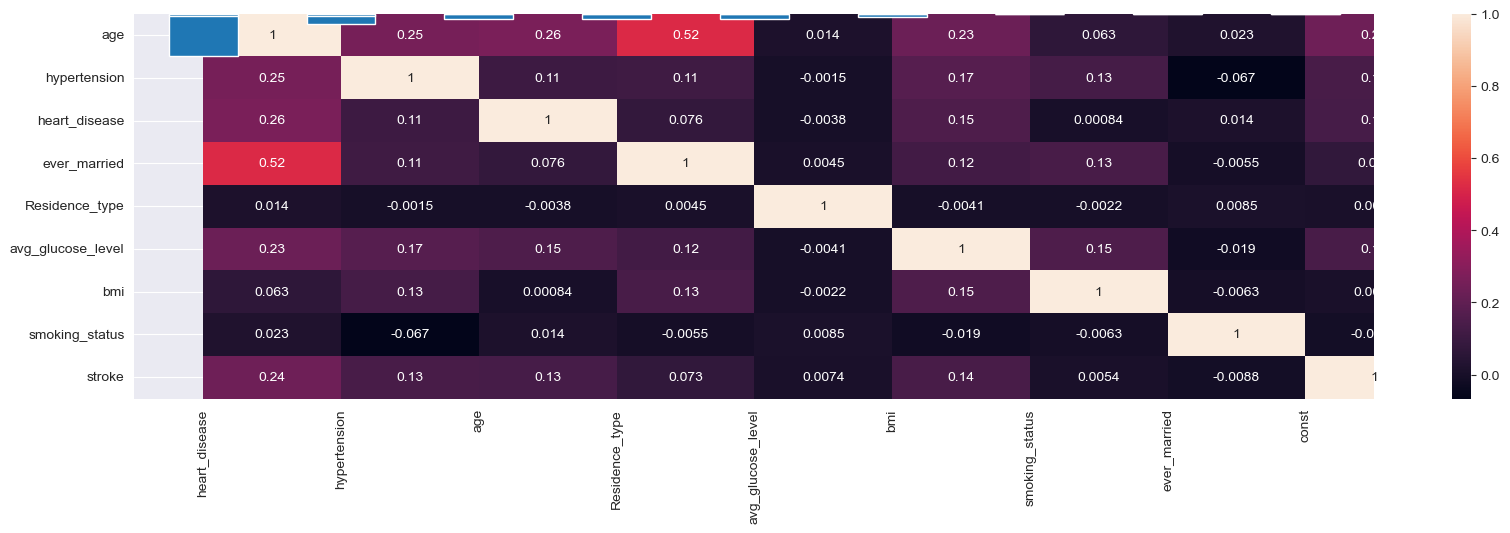

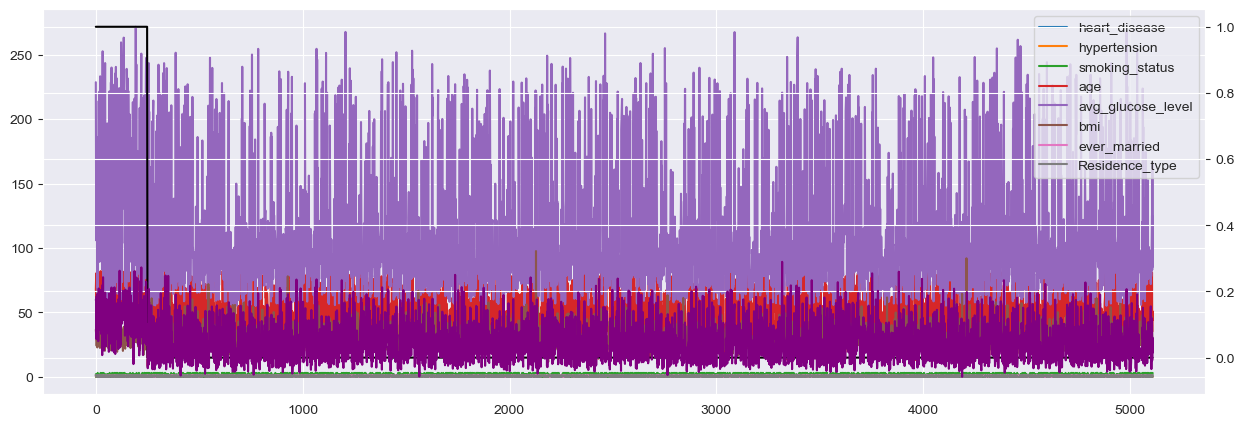

In [ ]:
prediction = regression_model.predict(independent_variables)

ax = dataframe[['heart_disease', 'hypertension','smoking_status','age','avg_glucose_level','bmi','ever_married','Residence_type']].plot(figsize=(15,5))
ax2 = ax.twinx()
ax2.plot(dataframe['stroke'], color='black', label='Stroke')
ax2.plot(prediction, color='purple', label='Prediction')
plt.show()